Métricas de clasificación binaria con dígitos

1. Problema: detectar si una imagen es un 5
Tomaremos el dataset load_digits de scikit-learn y construiremos una etiqueta binaria:

True: la imagen real es un 5.
False: la imagen real no es un 5.
Este cambio convierte un problema multiclase en un problema binario. Ya no preguntamos “¿qué dígito es?”, sino “¿pertenece a la clase positiva 5?”.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
plt.style.use("default")

In [2]:
digits = load_digits()
X = digits.data
y_multiclase = digits.target
y_es_5 = y_multiclase == 5
imagenes = digits.images

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables por imagen: {X.shape[1]}")
print(f"Cantidad de imágenes que son 5: {y_es_5.sum():,}")
print(f"Proporción de clase positiva: {y_es_5.mean():.3f}")

Observaciones: 1,797
Variables por imagen: 64
Cantidad de imágenes que son 5: 182
Proporción de clase positiva: 0.101


La clase positiva es relativamente minoritaria: solo una parte de las imágenes son 5. Esto es importante porque un modelo podría obtener una accuracy alta prediciendo casi siempre “no es 5”. Por eso necesitamos mirar más métricas.

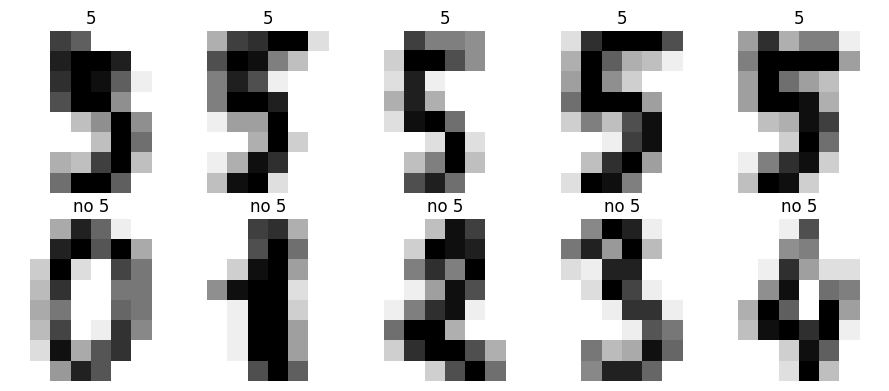

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
indices_5 = np.where(y_es_5)[0][:5]
indices_no_5 = np.where(~y_es_5)[0][:5]
indices = np.concatenate([indices_5, indices_no_5])

for indice, ax in zip(indices, axes.ravel()):
    ax.imshow(imagenes[indice], cmap="gray_r")
    etiqueta = "5" if y_es_5[indice] else "no 5"
    ax.set_title(etiqueta)
    ax.axis("off")

plt.tight_layout()
plt.show()

--------------------

2. Entrenamiento y prueba
Separaremos los datos en entrenamiento y prueba. Usaremos stratify=y_es_5 para mantener una proporción similar de imágenes 5 y no 5 en ambos conjuntos.

El conjunto de prueba se reserva para evaluar predicciones en ejemplos que el modelo no usó para aprender.

In [4]:
X_train, X_test, y_train, y_test, imagenes_train, imagenes_test = train_test_split(
    X,
    y_es_5,
    imagenes,
    test_size=0.25,
    stratify=y_es_5,
    random_state=RANDOM_STATE,
)

resumen = pd.DataFrame({
    "filas": [len(X_train), len(X_test)],
    "proporción_positiva": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])

display(resumen)

,filas,proporción_positiva
train,1347,0.100965
test,450,0.102222


In [7]:
X_train, X_test, y_train, y_test, imagenes_train, imagenes_test = train_test_split(
    X,
    y_es_5,
    imagenes,
    test_size=0.75,  # <--- Ahora el 75% es para test y el 25% para train
    stratify=y_es_5,
    random_state=RANDOM_STATE,
)

resumen = pd.DataFrame({
    "filas": [len(X_train), len(X_test)],
    "proporción_positiva": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])

display(resumen)

,filas,proporción_positiva
train,449,0.100223
test,1348,0.101632


----------------------------

3. Un primer clasificador binario
Entrenaremos un SGDClassifier. Este modelo puede entregar una predicción final con .predict(), pero también puede entregar un score de decisión con .decision_function().

El score es clave para entender umbrales: una observación con score más alto tiene más evidencia a favor de la clase positiva según el modelo.

In [5]:
clasificador_sgd = Pipeline(steps=[
    ("escalamiento", StandardScaler()),
    ("modelo", SGDClassifier(random_state=RANDOM_STATE)),
])

clasificador_sgd.fit(X_train, y_train)
y_pred_sgd = clasificador_sgd.predict(X_test)
scores_sgd = clasificador_sgd.decision_function(X_test)

print(f"Primeros scores: {np.round(scores_sgd[:10], 2)}")
print(f"Primeras predicciones: {y_pred_sgd[:10]}")

Primeros scores: [ -70.01  -83.22 -108.67 -235.94 -116.92 -131.28 -121.79  -71.99 -116.43
 -221.99]
Primeras predicciones: [False False False False False False False False False False]


Por defecto, el clasificador convierte scores en clases usando su regla interna de decisión. En un modelo lineal como este, un score mayor que cero suele quedar del lado positivo. Más adelante cambiaremos manualmente ese umbral para observar qué ocurre.

--------------------

4. Matriz de confusión binaria
La matriz de confusión binaria organiza los resultados en cuatro celdas. La figura del libro resume la lógica visualmente.

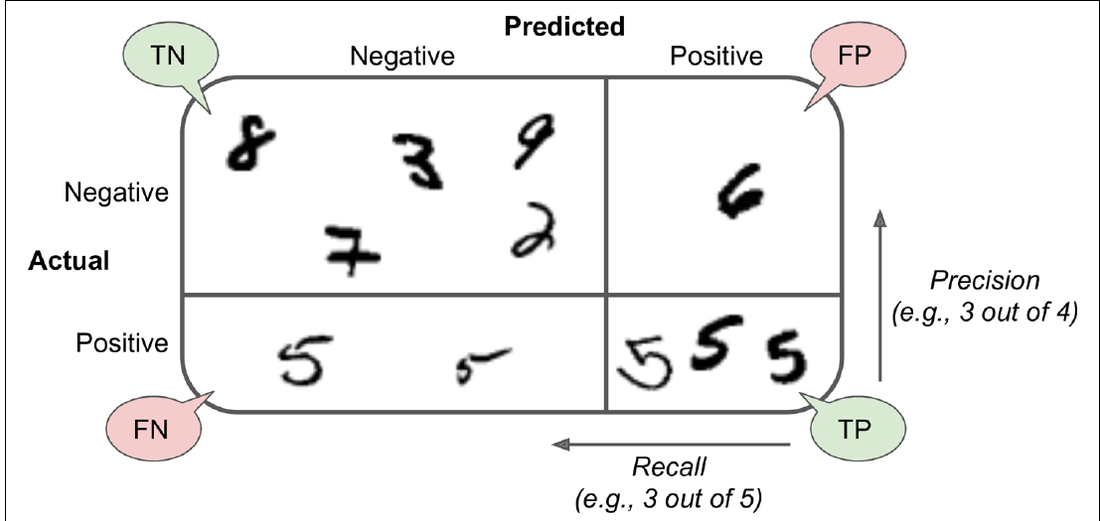

Matriz de confusión binaria ilustrada
En nuestro caso, positivo significa “es un 5”. Por lo tanto:

TP: imágenes que eran 5 y fueron predichas como 5.
FP: imágenes que no eran 5, pero fueron predichas como 5.
TN: imágenes que no eran 5 y fueron predichas como no 5.
FN: imágenes que eran 5, pero fueron predichas como no 5.

In [ ]:
cm = confusion_matrix(y_test, y_pred_sgd)
cm_df = pd.DataFrame(cm, index=["real_no_5", "real_5"], columns=["pred_no_5", "pred_5"])
display(cm_df)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_sgd,
    display_labels=["no 5", "5"],
    cmap="Blues",
    values_format="d",
    ax=ax,
)
ax.set_title("Matriz de confusión - detector de 5")
plt.tight_layout()
plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

Estos cuatro valores son la base de varias métricas. La accuracy mira todos los aciertos. La precisión se concentra en las predicciones positivas. El recall se concentra en los positivos reales.

---------------------------

5. Accuracy, precisión, recall y F1-score
Calculemos las métricas principales para el detector de 5.

Recuerda las preguntas:

Accuracy: ¿qué proporción total de predicciones fue correcta?
Precisión: cuando el modelo dijo “es 5”, ¿cuántas veces acertó?
Recall: de todos los 5 reales, ¿cuántos encontró?
F1-score: ¿qué tan equilibradas están precisión y recall?

In [ ]:
metricas_sgd = pd.DataFrame([{
    "accuracy": accuracy_score(y_test, y_pred_sgd),
    "precision": precision_score(y_test, y_pred_sgd, zero_division=0),
    "recall": recall_score(y_test, y_pred_sgd, zero_division=0),
    "f1": f1_score(y_test, y_pred_sgd, zero_division=0),
}], index=["SGDClassifier"])

display(metricas_sgd.style.format("{:.3f}"))
print(classification_report(y_test, y_pred_sgd, target_names=["no 5", "5"], zero_division=0))

Si la accuracy es alta, revisa igualmente precisión y recall. En este problema hay muchos más no 5 que 5, por lo que los aciertos sobre la clase negativa pueden dominar la accuracy.

----------------------

6. Umbral de decisión y trade-off precisión-recall
El capítulo base muestra que mover el umbral cambia el equilibrio entre precisión y recall.
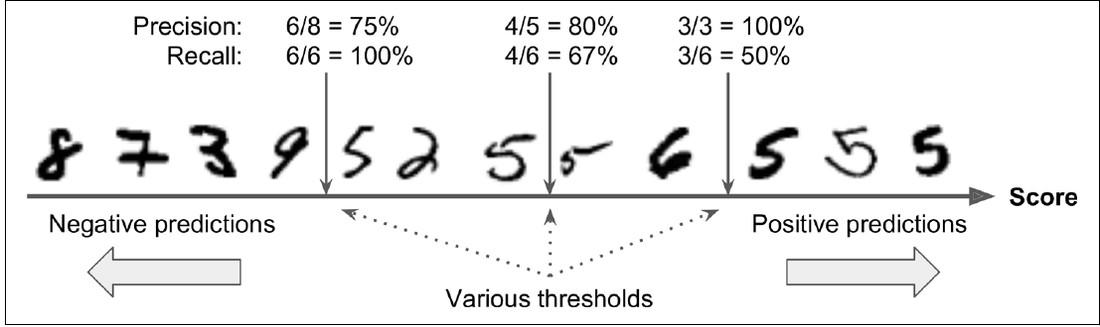
Trade-off entre precisión y recall según el umbral de decisión.
Usaremos los scores del modelo para probar distintos umbrales. Un umbral más alto exige más evidencia para decir “es 5”. Un umbral más bajo hace que el modelo prediga más positivos.

In [ ]:
def metricas_para_umbral(threshold):
    y_pred_threshold = scores_sgd >= threshold
    return {
        "threshold": threshold,
        "positivos_predichos": int(y_pred_threshold.sum()),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
    }

thresholds_a_probar = [-5, 0, 5, 10]
tabla_thresholds = pd.DataFrame([metricas_para_umbral(t) for t in thresholds_a_probar])
display(tabla_thresholds.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"}))

Observa cómo cambia la cantidad de positivos predichos. Cuando el umbral sube, normalmente hay menos predicciones positivas. Eso puede mejorar la precisión, pero también puede dejar fuera algunos 5 reales y bajar el recall.

------------------

7. Curva precision-recall
La curva precision-recall resume el comportamiento del clasificador para muchos umbrales posibles. Es útil cuando la clase positiva es poco frecuente o cuando nos interesa especialmente la calidad de las predicciones positivas.

In [ ]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, scores_sgd)
average_precision = average_precision_score(y_test, scores_sgd)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recalls, precisions, color="#4C78A8")
ax.set_title(f"Curva precision-recall (AP={average_precision:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precisión")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Cada punto de la curva representa un umbral distinto. Una curva más cercana a la esquina superior derecha indica un mejor equilibrio: alto recall y alta precisión al mismo tiempo.

In [ ]:
precision_threshold = precisions[:-1]
recall_threshold = recalls[:-1]
f1_threshold = 2 * precision_threshold * recall_threshold / (precision_threshold + recall_threshold + 1e-12)
mejor_indice = int(np.nanargmax(f1_threshold))
threshold_f1 = float(pr_thresholds[mejor_indice])

print(f"Threshold que maximiza F1 en test: {threshold_f1:.3f}")
print(f"Precisión: {precision_threshold[mejor_indice]:.3f}")
print(f"Recall: {recall_threshold[mejor_indice]:.3f}")
print(f"F1: {f1_threshold[mejor_indice]:.3f}")

8. Curva ROC y AUC
La curva ROC grafica la tasa de verdaderos positivos contra la tasa de falsos positivos. La figura del libro muestra la intuición: una curva más cerca de la esquina superior izquierda indica mejor separación entre positivos y negativos.

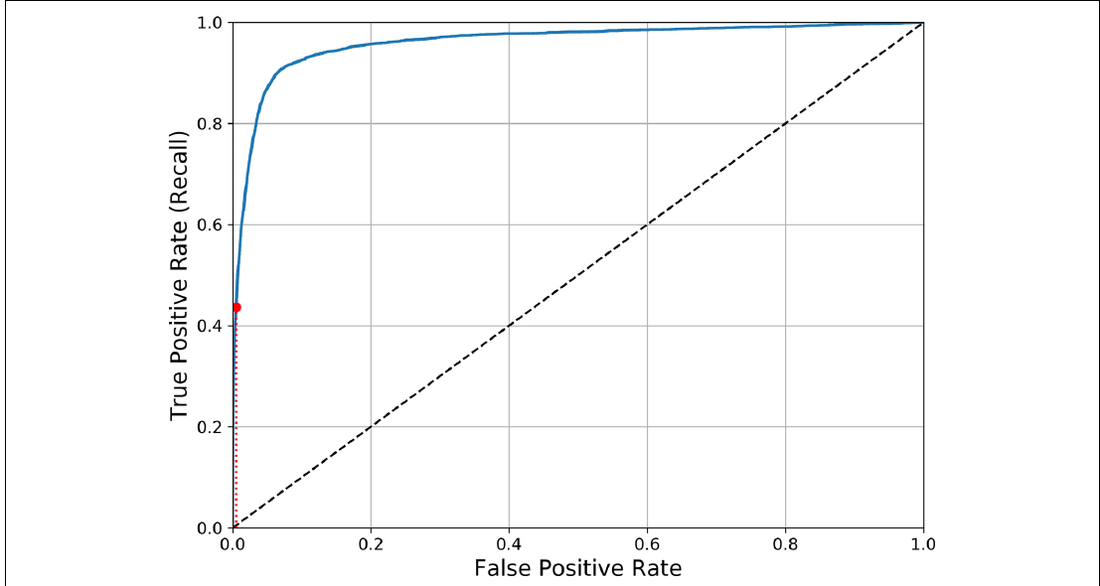

Curva ROC para un clasificador binario.
El AUC resume el área bajo esa curva. Un valor cercano a 1.0 indica buena separación; un valor cercano a 0.5 se parece a una decisión aleatoria.

In [ ]:
fpr_sgd, tpr_sgd, roc_thresholds = roc_curve(y_test, scores_sgd)
auc_sgd = roc_auc_score(y_test, scores_sgd)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr_sgd, tpr_sgd, label=f"SGDClassifier (AUC={auc_sgd:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="azar")
ax.set_title("Curva ROC")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ROC y precision-recall miran el problema desde ángulos distintos. En clases muy desbalanceadas, la curva precision-recall suele mostrar con más claridad si las predicciones positivas son confiables.

------------------

9. Comparación con Random Forest
Para cerrar, comparemos el SGDClassifier con un RandomForestClassifier. El bosque no usa decision_function, pero sí puede entregar probabilidades con .predict_proba(). Usaremos la probabilidad de la clase positiva como score.


In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
scores_rf = random_forest.predict_proba(X_test)[:, 1]

comparacion = pd.DataFrame([
    {
        "modelo": "SGDClassifier",
        "accuracy": accuracy_score(y_test, y_pred_sgd),
        "precision": precision_score(y_test, y_pred_sgd, zero_division=0),
        "recall": recall_score(y_test, y_pred_sgd, zero_division=0),
        "f1": f1_score(y_test, y_pred_sgd, zero_division=0),
        "roc_auc": roc_auc_score(y_test, scores_sgd),
        "average_precision": average_precision_score(y_test, scores_sgd),
    },
    {
        "modelo": "RandomForestClassifier",
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "precision": precision_score(y_test, y_pred_rf, zero_division=0),
        "recall": recall_score(y_test, y_pred_rf, zero_division=0),
        "f1": f1_score(y_test, y_pred_rf, zero_division=0),
        "roc_auc": roc_auc_score(y_test, scores_rf),
        "average_precision": average_precision_score(y_test, scores_rf),
    },
]).set_index("modelo")

display(comparacion.style.format("{:.3f}"))

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, scores_rf)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr_sgd, tpr_sgd, label=f"SGD (AUC={auc_sgd:.3f})")
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, scores_rf):.3f})")
ax.plot([0, 1], [0, 1], "k--", label="azar")
ax.set_title("Comparación de curvas ROC")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La comparación no debe quedarse solo en una métrica. Si un modelo tiene mayor AUC, también conviene revisar precisión, recall, F1 y la matriz de confusión al umbral que realmente se usará. La mejor elección depende del costo de los falsos positivos y falsos negativos.

--------------------------------------------------------------------------------------------

10. Actividad práctica
Cambia el dígito positivo: usa y_multiclase == 3 o y_multiclase == 8. ¿Cambian las métricas?
Prueba otros umbrales y explica cómo cambian precisión y recall.
Elige un umbral que priorice recall. ¿Qué costo tiene en falsos positivos?
Elige un umbral que priorice precisión. ¿Qué costo tiene en falsos negativos?
Compara SGDClassifier y RandomForestClassifier usando F1, curva precision-recall y ROC AUC.
Escribe una conclusión breve: si el objetivo fuera no perder ningún 5, ¿qué métrica priorizarías? ¿Y si el objetivo fuera evitar falsas alarmas?

------------------------

11. Conclusiones
En esta actividad convertimos un problema multiclase en una pregunta binaria: detectar si una imagen es un 5. Esta transformación nos permitió estudiar con más claridad los cuatro tipos de resultado de una matriz de confusión binaria: TP, FP, TN y FN.

También vimos que accuracy no siempre basta. Precisión, recall y F1-score responden preguntas distintas, y el umbral de decisión permite mover el equilibrio entre detectar más positivos o ser más estricto al declarar una predicción positiva.

Finalmente, las curvas precision-recall y ROC permiten evaluar modelos a través de muchos umbrales posibles. AUC resume la curva ROC, pero la interpretación siempre debe conectarse con el problema: qué error cuesta más y qué decisión se tomará con el modelo.